  MODÈLE ML — PRÉDICTION DU CHURN TÉLÉCOM

[1/6] Extraction des données depuis le Data Warehouse...
   Clients extraits   : 4998
   Churné (1)         : 1448
   Actif  (0)         : 3550
   Taux de churn      : 29.0%

[2/6] Feature engineering...
   Features utilisées : 15

[3/6] Split 80/20 + SMOTE...
   Train avant SMOTE  : {0: np.int64(2840), 1: np.int64(1158)}
   Train après SMOTE  : {0: np.int64(2840), 1: np.int64(2840)}
   Test               : {0: np.int64(710), 1: np.int64(290)}

[4/6] Entraînement XGBoost...
   AUC-ROC CV 5-fold  : 0.9128 ± 0.0069

[5/6] Évaluation et visualisation...


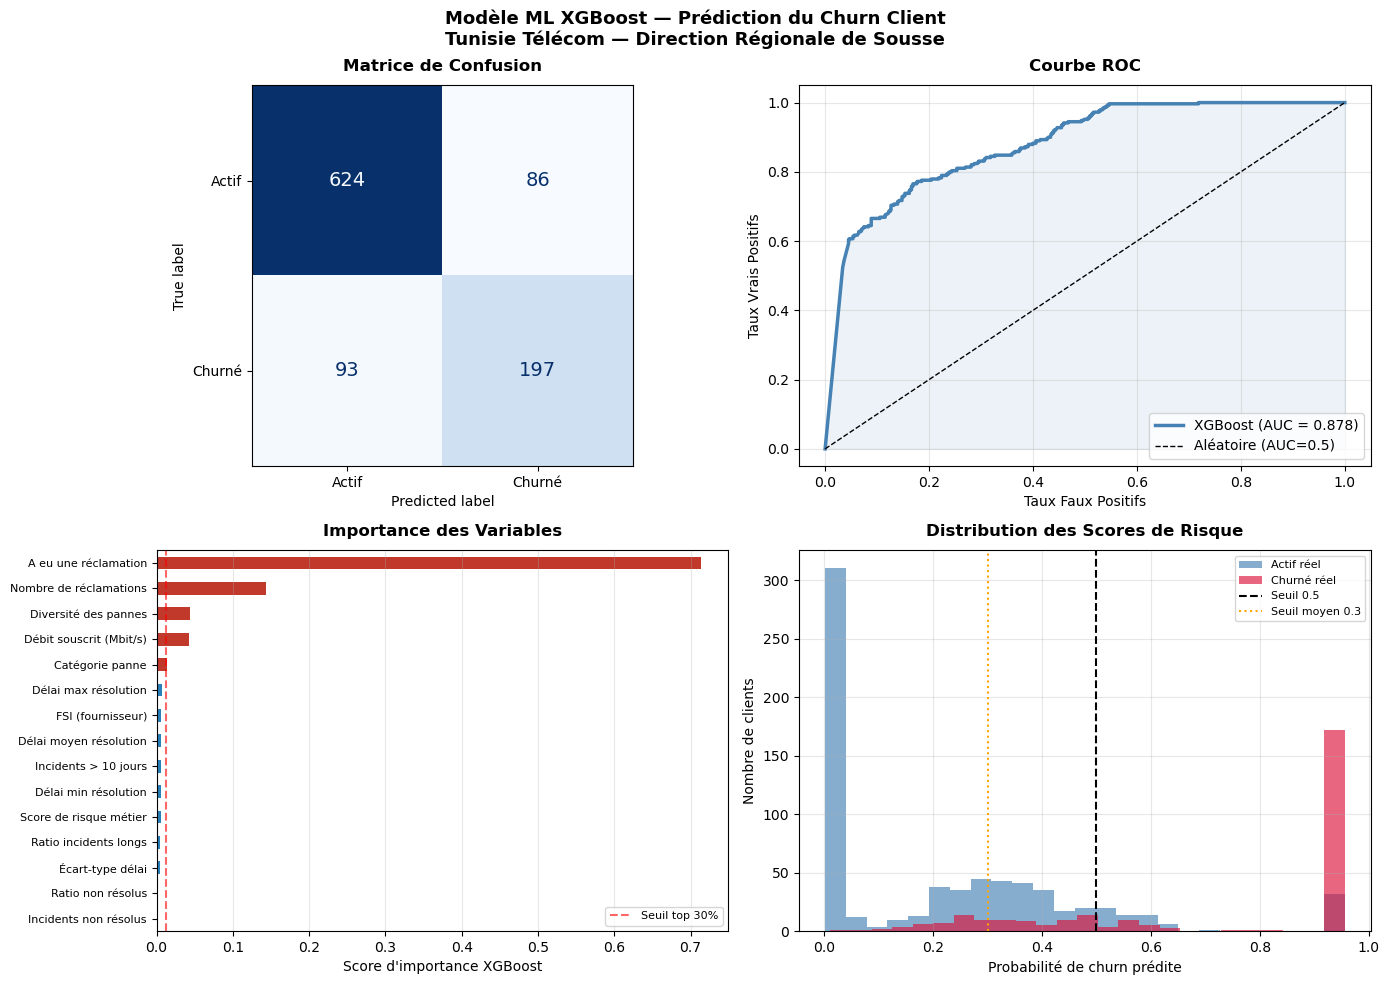

   Figures sauvegardées : ml_churn_evaluation.png

[6/6] Export scores vers Data Warehouse...
   Scores exportés dans dw.dim_client ✓

  SEGMENTATION CLIENTS PAR RISQUE DE CHURN
           Nb Clients  Churné Réel  Taux Churn %  Score Moyen
risque_ml                                                    
Faible           2435           90           3.7        0.096
Moyen            1435          377          26.3        0.423
Haut             1128          981          87.0        0.921

  MÉTRIQUES D'ÉVALUATION DU MODÈLE XGBOOST
              precision    recall  f1-score   support

   Actif (0)       0.87      0.88      0.87       710
  Churné (1)       0.70      0.68      0.69       290

    accuracy                           0.82      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.82      0.82      0.82      1000

  AUC-ROC final      : 0.8785
  AUC-ROC CV 5-fold  : 0.9128 ± 0.0069

  MODÈLE TERMINÉ AVEC SUCCÈS


In [5]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
 
import sqlalchemy as sa
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
 
# ============================================================
#  CONFIGURATION
# ============================================================
DB_USER     = "postgres"
DB_PASSWORD = "pfe2025"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "dw_telecom"
 
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    connect_args={"options": "-csearch_path=dw"}
)
 
print("=" * 60)
print("  MODÈLE ML — PRÉDICTION DU CHURN TÉLÉCOM")
print("=" * 60)
 
# ============================================================
#  ÉTAPE 1 : EXTRACTION
# ============================================================
print("\n[1/6] Extraction des données depuis le Data Warehouse...")
 
query = """
SELECT
    cl.id_client,
    cl.est_resilie::int AS churn,
    COUNT(fd.id_incident) AS nb_reclamations,
    COALESCE(AVG(fd.duree_resolution_jours), 0) AS delai_moy_resolution,
    COALESCE(MAX(fd.duree_resolution_jours), 0) AS delai_max_resolution,
    COALESCE(MIN(fd.duree_resolution_jours), 0) AS delai_min_resolution,
    COALESCE(STDDEV(fd.duree_resolution_jours),0) AS delai_std_resolution,
    SUM(CASE WHEN fd.duree_resolution_jours > 10 THEN 1 ELSE 0 END) AS nb_incidents_longs,
    SUM(CASE WHEN fd.etat_alerte = 'En cours' THEN 1 ELSE 0 END) AS nb_non_resolus,
    COUNT(DISTINCT c.categorie_reclamation) AS nb_categories_distinctes,
    CASE
        WHEN cl.debit_souscrit LIKE '%8%'   THEN 8
        WHEN cl.debit_souscrit LIKE '%10%'  THEN 10
        WHEN cl.debit_souscrit LIKE '%20%'  THEN 20
        WHEN cl.debit_souscrit LIKE '%30%'  THEN 30
        WHEN cl.debit_souscrit LIKE '%50%'  THEN 50
        WHEN cl.debit_souscrit LIKE '%100%' THEN 100
        ELSE 0
    END AS debit_num,
    COALESCE(f.nom_fsi, 'Inconnu') AS nom_fsi,
    COALESCE(MODE() WITHIN GROUP (ORDER BY c.categorie_reclamation), 'Aucune') AS categorie_dominante
FROM dw.dim_client cl
LEFT JOIN dw.fact_derangement fd ON cl.id_client    = fd.id_client
LEFT JOIN dw.dim_fsi           f  ON fd.id_fsi       = f.id_fsi
LEFT JOIN dw.dim_categorie     c  ON fd.id_categorie = c.id_categorie
GROUP BY cl.id_client, cl.est_resilie, cl.debit_souscrit, f.nom_fsi
"""
 
with engine.connect() as conn:
    df = pd.read_sql(sa.text(query), conn)
 
print(f"   Clients extraits   : {len(df)}")
print(f"   Churné (1)         : {df['churn'].sum()}")
print(f"   Actif  (0)         : {(df['churn']==0).sum()}")
print(f"   Taux de churn      : {df['churn'].mean()*100:.1f}%")
 
# ============================================================
#  ÉTAPE 2 : FEATURE ENGINEERING
# ============================================================
print("\n[2/6] Feature engineering...")
 
le_fsi = LabelEncoder()
le_cat = LabelEncoder()
df['fsi_encoded'] = le_fsi.fit_transform(df['nom_fsi'])
df['cat_encoded'] = le_cat.fit_transform(df['categorie_dominante'])
df['a_eu_reclamation']      = (df['nb_reclamations'] > 0).astype(int)
df['ratio_non_resolu']      = np.where(df['nb_reclamations']>0,
                                        df['nb_non_resolus']/df['nb_reclamations'], 0)
df['ratio_incidents_longs'] = np.where(df['nb_reclamations']>0,
                                        df['nb_incidents_longs']/df['nb_reclamations'], 0)
df['score_risque'] = (df['nb_reclamations']*2.0 + df['nb_non_resolus']*3.0 +
                      df['nb_incidents_longs']*1.5 + df['delai_moy_resolution']*0.3)
 
FEATURES = [
    'nb_reclamations', 'delai_moy_resolution', 'delai_max_resolution',
    'delai_min_resolution', 'delai_std_resolution', 'nb_incidents_longs',
    'nb_non_resolus', 'nb_categories_distinctes', 'a_eu_reclamation',
    'ratio_non_resolu', 'ratio_incidents_longs', 'score_risque',
    'debit_num', 'fsi_encoded', 'cat_encoded'
]
 
X = df[FEATURES].fillna(0)
y = df['churn']
print(f"   Features utilisées : {len(FEATURES)}")
 
# ============================================================
#  ÉTAPE 3 : SPLIT + SMOTE
# ============================================================
print("\n[3/6] Split 80/20 + SMOTE...")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
 
print(f"   Train avant SMOTE  : {dict(y_train.value_counts())}")
print(f"   Train après SMOTE  : {dict(pd.Series(y_train_sm).value_counts())}")
print(f"   Test               : {dict(y_test.value_counts())}")
 
# ============================================================
#  ÉTAPE 4 : ENTRAÎNEMENT XGBOOST
# ============================================================
print("\n[4/6] Entraînement XGBoost...")
 
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=1, reg_alpha=0.1, reg_lambda=1,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_train_sm, y_train_sm, cv=cv, scoring='roc_auc')
print(f"   AUC-ROC CV 5-fold  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
 
# ============================================================
#  ÉTAPE 5 : ÉVALUATION + VISUALISATIONS
# ============================================================
print("\n[5/6] Évaluation et visualisation...")
 
y_pred      = xgb.predict(X_test)
y_pred_prob = xgb.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)
 
# ── FIGURES ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Modèle ML XGBoost — Prédiction du Churn Client\n"
    "Tunisie Télécom — Direction Régionale de Sousse",
    fontsize=13, fontweight='bold'
)
 
# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Actif','Churné'])
disp.plot(ax=axes[0,0], colorbar=False, cmap='Blues')
axes[0,0].set_title('Matrice de Confusion', fontweight='bold', pad=10)
for text in axes[0,0].texts:
    text.set_fontsize(14)
 
# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0,1].plot(fpr, tpr, color='steelblue', lw=2.5,
               label=f'XGBoost (AUC = {auc:.3f})')
axes[0,1].plot([0,1],[0,1],'k--',lw=1,label='Aléatoire (AUC=0.5)')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0,1].set_xlabel('Taux Faux Positifs')
axes[0,1].set_ylabel('Taux Vrais Positifs')
axes[0,1].set_title('Courbe ROC', fontweight='bold', pad=10)
axes[0,1].legend(loc='lower right')
axes[0,1].grid(alpha=0.3)
 
# 3. Feature Importance
labels_fr = {
    'nb_reclamations'        : 'Nombre de réclamations',
    'delai_moy_resolution'   : 'Délai moyen résolution',
    'delai_max_resolution'   : 'Délai max résolution',
    'delai_min_resolution'   : 'Délai min résolution',
    'delai_std_resolution'   : 'Écart-type délai',
    'nb_incidents_longs'     : 'Incidents > 10 jours',
    'nb_non_resolus'         : 'Incidents non résolus',
    'nb_categories_distinctes': 'Diversité des pannes',
    'a_eu_reclamation'       : 'A eu une réclamation',
    'ratio_non_resolu'       : 'Ratio non résolus',
    'ratio_incidents_longs'  : 'Ratio incidents longs',
    'score_risque'           : 'Score de risque métier',
    'debit_num'              : 'Débit souscrit (Mbit/s)',
    'fsi_encoded'            : 'FSI (fournisseur)',
    'cat_encoded'            : 'Catégorie panne'
}
imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()
colors = ['#c0392b' if v >= imp.quantile(0.7) else '#2980b9' for v in imp]
imp.plot(kind='barh', ax=axes[1,0], color=colors)
axes[1,0].set_yticklabels([labels_fr.get(f,f) for f in imp.index], fontsize=8)
axes[1,0].set_title('Importance des Variables', fontweight='bold', pad=10)
axes[1,0].set_xlabel("Score d'importance XGBoost")
axes[1,0].axvline(imp.quantile(0.7), color='red', linestyle='--',
                   alpha=0.6, label='Seuil top 30%')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(alpha=0.3, axis='x')
 
# 4. Distribution scores de risque
df_viz = pd.DataFrame({'prob': y_pred_prob, 'reel': y_test.values})
axes[1,1].hist(df_viz[df_viz['reel']==0]['prob'],
               bins=25, alpha=0.65, color='steelblue', label='Actif réel')
axes[1,1].hist(df_viz[df_viz['reel']==1]['prob'],
               bins=25, alpha=0.65, color='crimson', label='Churné réel')
axes[1,1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Seuil 0.5')
axes[1,1].axvline(0.3, color='orange', linestyle=':', lw=1.5, label='Seuil moyen 0.3')
axes[1,1].set_xlabel('Probabilité de churn prédite')
axes[1,1].set_ylabel('Nombre de clients')
axes[1,1].set_title('Distribution des Scores de Risque', fontweight='bold', pad=10)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('ml_churn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Figures sauvegardées : ml_churn_evaluation.png")
 
# ============================================================
#  ÉTAPE 6 : EXPORT SCORES → DW
# ============================================================
print("\n[6/6] Export scores vers Data Warehouse...")
 
prob_all     = xgb.predict_proba(X)[:, 1]
df['score_churn'] = prob_all.round(4)
df['risque_ml']   = pd.cut(prob_all, bins=[0,0.3,0.6,1.0],
                            labels=['Faible','Moyen','Haut'])
 
with engine.connect() as conn:
    try:
        conn.execute(sa.text(
            "ALTER TABLE dw.dim_client ADD COLUMN IF NOT EXISTS score_churn_ml NUMERIC(5,4)"))
        conn.execute(sa.text(
            "ALTER TABLE dw.dim_client ADD COLUMN IF NOT EXISTS categorie_risque_ml VARCHAR(10)"))
        conn.commit()
    except: pass
 
    for _, row in df.iterrows():
        conn.execute(
            sa.text("""
                UPDATE dw.dim_client
                SET score_churn_ml = :score, categorie_risque_ml = :cat
                WHERE id_client = :id
            """),
      
             {"score": float(row['score_churn']),
             "cat":   str(row['risque_ml']),
             "id":    int(row['id_client'])}
        )
    conn.commit()
 
print("   Scores exportés dans dw.dim_client ✓")
 
print("\n" + "=" * 60)
print("  SEGMENTATION CLIENTS PAR RISQUE DE CHURN")
print("=" * 60)r
resume = df.groupby('risque_ml', observed=True).agg(
    nb_clients      = ('id_client','count'),
    churne_reel     = ('churn','sum'),
    taux_churn      = ('churn','mean'),
    score_moyen     = ('score_churn','mean')
).round(3)
resume['taux_churn'] = (resume['taux_churn']*100).round(1)
resume.columns = ['Nb Clients','Churné Réel','Taux Churn %','Score Moyen']
print(resume.to_string())
 
print("\n" + "=" * 60)
print("  MÉTRIQUES D'ÉVALUATION DU MODÈLE XGBOOST")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=['Actif (0)','Churné (1)']))
print(f"  AUC-ROC final      : {auc:.4f}")
print(f"  AUC-ROC CV 5-fold  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 60)
print("\n  MODÈLE TERMINÉ AVEC SUCCÈS")

  MODÈLE ML — PRÉDICTION DU CHURN TÉLÉCOM

[1/6] Extraction des données depuis le Data Warehouse...
   Clients extraits   : 4998
   Churné (1)         : 1448
   Actif  (0)         : 3550
   Taux de churn      : 29.0%

[2/6] Feature engineering...
   Features utilisées : 15

[3/6] Split 80/20 + SMOTE...
   Train avant SMOTE  : {0: np.int64(2840), 1: np.int64(1158)}
   Train après SMOTE  : {0: np.int64(2840), 1: np.int64(2840)}
   Test               : {0: np.int64(710), 1: np.int64(290)}

[4/6] Entraînement XGBoost...
   AUC-ROC CV 5-fold  : 0.9128 ± 0.0069

[5/6] Évaluation et visualisation...


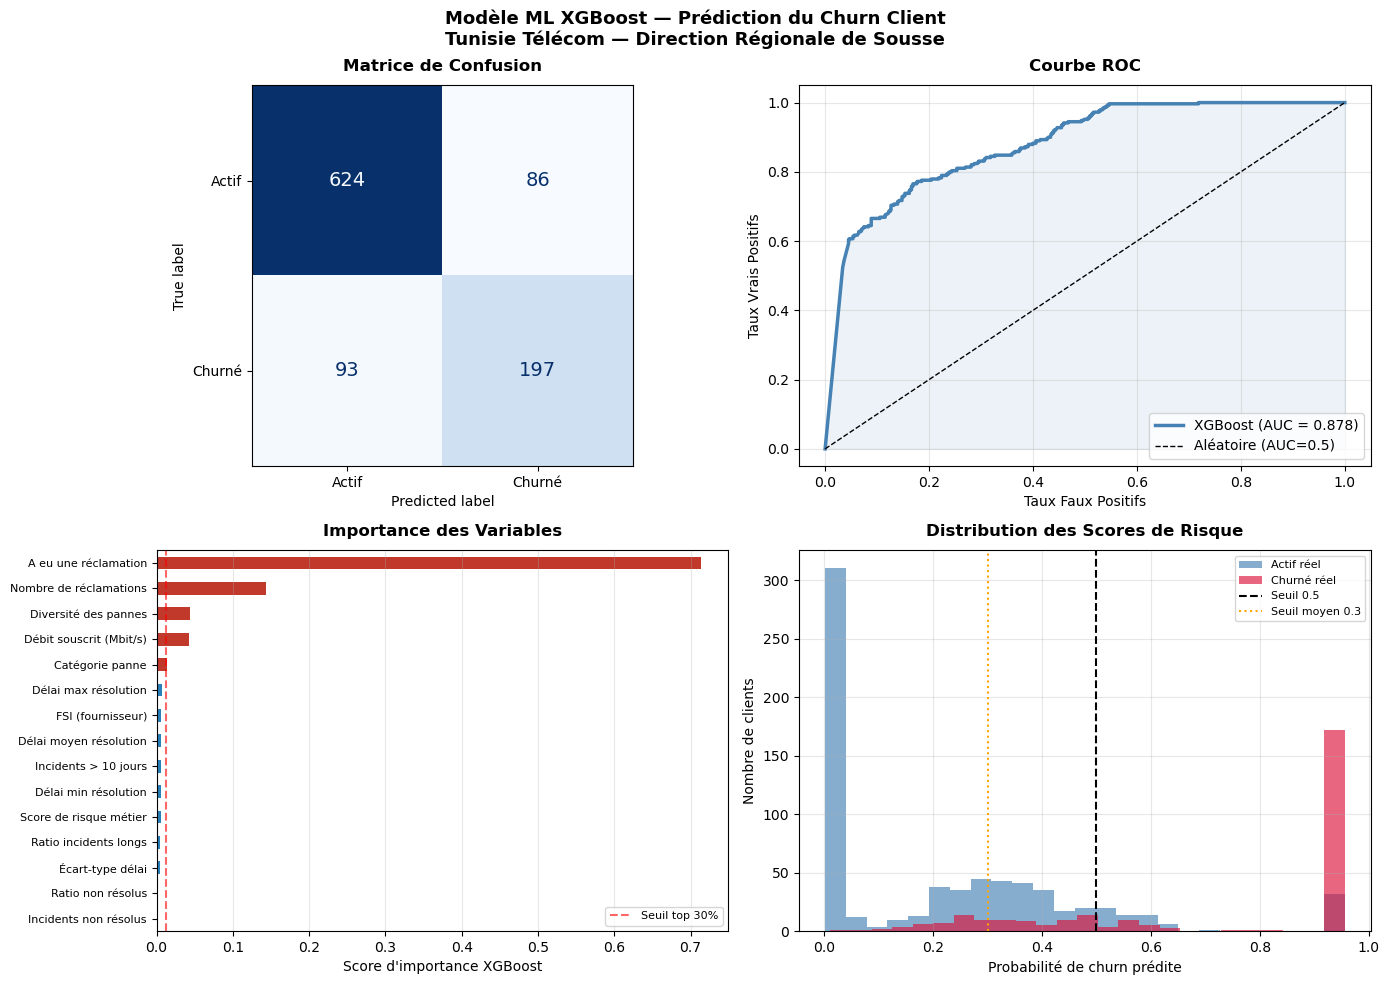

   Figures sauvegardées : ml_churn_evaluation.png

[6/6] Export scores vers Data Warehouse...
   Scores exportés dans dw.dim_client ✓

  SEGMENTATION CLIENTS PAR RISQUE DE CHURN
           Nb Clients  Churné Réel  Taux Churn %  Score Moyen
risque_ml                                                    
Faible           2435           90           3.7        0.096
Moyen            1435          377          26.3        0.423
Haut             1128          981          87.0        0.921

  MÉTRIQUES D'ÉVALUATION DU MODÈLE XGBOOST
              precision    recall  f1-score   support

   Actif (0)       0.87      0.88      0.87       710
  Churné (1)       0.70      0.68      0.69       290

    accuracy                           0.82      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.82      0.82      0.82      1000

  AUC-ROC final      : 0.8785
  AUC-ROC CV 5-fold  : 0.9128 ± 0.0069

  MODÈLE TERMINÉ AVEC SUCCÈS


In [1]:
# ============================================================
#  MODÈLE ML COMPLET — PRÉDICTION DU CHURN CLIENT
#  Tunisie Télécom — Direction Régionale de Sousse
#  Visualisations + Métriques + Export DW + Segmentation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sqlalchemy as sa
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ============================================================
#  CONFIGURATION
# ============================================================
DB_USER     = "postgres"
DB_PASSWORD = "pfe2025"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "dw_telecom"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    connect_args={"options": "-csearch_path=dw"}
)

print("=" * 60)
print("  MODÈLE ML — PRÉDICTION DU CHURN TÉLÉCOM")
print("=" * 60)

# ============================================================
#  ÉTAPE 1 : EXTRACTION
# ============================================================
print("\n[1/6] Extraction des données depuis le Data Warehouse...")

query = """
SELECT
    cl.id_client,
    cl.est_resilie::int AS churn,
    COUNT(fd.id_incident) AS nb_reclamations,
    COALESCE(AVG(fd.duree_resolution_jours), 0) AS delai_moy_resolution,
    COALESCE(MAX(fd.duree_resolution_jours), 0) AS delai_max_resolution,
    COALESCE(MIN(fd.duree_resolution_jours), 0) AS delai_min_resolution,
    COALESCE(STDDEV(fd.duree_resolution_jours),0) AS delai_std_resolution,
    SUM(CASE WHEN fd.duree_resolution_jours > 10 THEN 1 ELSE 0 END) AS nb_incidents_longs,
    SUM(CASE WHEN fd.etat_alerte = 'En cours' THEN 1 ELSE 0 END) AS nb_non_resolus,
    COUNT(DISTINCT c.categorie_reclamation) AS nb_categories_distinctes,
    CASE
        WHEN cl.debit_souscrit LIKE '%8%'   THEN 8
        WHEN cl.debit_souscrit LIKE '%10%'  THEN 10
        WHEN cl.debit_souscrit LIKE '%20%'  THEN 20
        WHEN cl.debit_souscrit LIKE '%30%'  THEN 30
        WHEN cl.debit_souscrit LIKE '%50%'  THEN 50
        WHEN cl.debit_souscrit LIKE '%100%' THEN 100
        ELSE 0
    END AS debit_num,
    COALESCE(f.nom_fsi, 'Inconnu') AS nom_fsi,
    COALESCE(MODE() WITHIN GROUP (ORDER BY c.categorie_reclamation), 'Aucune') AS categorie_dominante
FROM dw.dim_client cl
LEFT JOIN dw.fact_derangement fd ON cl.id_client    = fd.id_client
LEFT JOIN dw.dim_fsi           f  ON fd.id_fsi       = f.id_fsi
LEFT JOIN dw.dim_categorie     c  ON fd.id_categorie = c.id_categorie
GROUP BY cl.id_client, cl.est_resilie, cl.debit_souscrit, f.nom_fsi
"""

with engine.connect() as conn:
    df = pd.read_sql(sa.text(query), conn)

print(f"   Clients extraits   : {len(df)}")
print(f"   Churné (1)         : {df['churn'].sum()}")
print(f"   Actif  (0)         : {(df['churn']==0).sum()}")
print(f"   Taux de churn      : {df['churn'].mean()*100:.1f}%")

# ============================================================
#  ÉTAPE 2 : FEATURE ENGINEERING
# ============================================================
print("\n[2/6] Feature engineering...")

le_fsi = LabelEncoder()
le_cat = LabelEncoder()
df['fsi_encoded'] = le_fsi.fit_transform(df['nom_fsi'])
df['cat_encoded'] = le_cat.fit_transform(df['categorie_dominante'])
df['a_eu_reclamation']      = (df['nb_reclamations'] > 0).astype(int)
df['ratio_non_resolu']      = np.where(df['nb_reclamations']>0,
                                        df['nb_non_resolus']/df['nb_reclamations'], 0)
df['ratio_incidents_longs'] = np.where(df['nb_reclamations']>0,
                                        df['nb_incidents_longs']/df['nb_reclamations'], 0)
df['score_risque'] = (df['nb_reclamations']*2.0 + df['nb_non_resolus']*3.0 +
                      df['nb_incidents_longs']*1.5 + df['delai_moy_resolution']*0.3)

FEATURES = [
    'nb_reclamations', 'delai_moy_resolution', 'delai_max_resolution',
    'delai_min_resolution', 'delai_std_resolution', 'nb_incidents_longs',
    'nb_non_resolus', 'nb_categories_distinctes', 'a_eu_reclamation',
    'ratio_non_resolu', 'ratio_incidents_longs', 'score_risque',
    'debit_num', 'fsi_encoded', 'cat_encoded'
]

X = df[FEATURES].fillna(0)
y = df['churn']
print(f"   Features utilisées : {len(FEATURES)}")

# ============================================================
#  ÉTAPE 3 : SPLIT + SMOTE
# ============================================================
print("\n[3/6] Split 80/20 + SMOTE...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"   Train avant SMOTE  : {dict(y_train.value_counts())}")
print(f"   Train après SMOTE  : {dict(pd.Series(y_train_sm).value_counts())}")
print(f"   Test               : {dict(y_test.value_counts())}")

# ============================================================
#  ÉTAPE 4 : ENTRAÎNEMENT XGBOOST
# ============================================================
print("\n[4/6] Entraînement XGBoost...")

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=1, reg_alpha=0.1, reg_lambda=1,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_train_sm, y_train_sm, cv=cv, scoring='roc_auc')
print(f"   AUC-ROC CV 5-fold  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ============================================================
#  ÉTAPE 5 : ÉVALUATION + VISUALISATIONS
# ============================================================
print("\n[5/6] Évaluation et visualisation...")

y_pred      = xgb.predict(X_test)
y_pred_prob = xgb.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)

# ── FIGURES ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Modèle ML XGBoost — Prédiction du Churn Client\n"
    "Tunisie Télécom — Direction Régionale de Sousse",
    fontsize=13, fontweight='bold'
)

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Actif','Churné'])
disp.plot(ax=axes[0,0], colorbar=False, cmap='Blues')
axes[0,0].set_title('Matrice de Confusion', fontweight='bold', pad=10)
for text in axes[0,0].texts:
    text.set_fontsize(14)

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0,1].plot(fpr, tpr, color='steelblue', lw=2.5,
               label=f'XGBoost (AUC = {auc:.3f})')
axes[0,1].plot([0,1],[0,1],'k--',lw=1,label='Aléatoire (AUC=0.5)')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0,1].set_xlabel('Taux Faux Positifs')
axes[0,1].set_ylabel('Taux Vrais Positifs')
axes[0,1].set_title('Courbe ROC', fontweight='bold', pad=10)
axes[0,1].legend(loc='lower right')
axes[0,1].grid(alpha=0.3)

# 3. Feature Importance
labels_fr = {
    'nb_reclamations'        : 'Nombre de réclamations',
    'delai_moy_resolution'   : 'Délai moyen résolution',
    'delai_max_resolution'   : 'Délai max résolution',
    'delai_min_resolution'   : 'Délai min résolution',
    'delai_std_resolution'   : 'Écart-type délai',
    'nb_incidents_longs'     : 'Incidents > 10 jours',
    'nb_non_resolus'         : 'Incidents non résolus',
    'nb_categories_distinctes': 'Diversité des pannes',
    'a_eu_reclamation'       : 'A eu une réclamation',
    'ratio_non_resolu'       : 'Ratio non résolus',
    'ratio_incidents_longs'  : 'Ratio incidents longs',
    'score_risque'           : 'Score de risque métier',
    'debit_num'              : 'Débit souscrit (Mbit/s)',
    'fsi_encoded'            : 'FSI (fournisseur)',
    'cat_encoded'            : 'Catégorie panne'
}
imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()
colors = ['#c0392b' if v >= imp.quantile(0.7) else '#2980b9' for v in imp]
imp.plot(kind='barh', ax=axes[1,0], color=colors)
axes[1,0].set_yticklabels([labels_fr.get(f,f) for f in imp.index], fontsize=8)
axes[1,0].set_title('Importance des Variables', fontweight='bold', pad=10)
axes[1,0].set_xlabel("Score d'importance XGBoost")
axes[1,0].axvline(imp.quantile(0.7), color='red', linestyle='--',
                   alpha=0.6, label='Seuil top 30%')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(alpha=0.3, axis='x')

# 4. Distribution scores de risque
df_viz = pd.DataFrame({'prob': y_pred_prob, 'reel': y_test.values})
axes[1,1].hist(df_viz[df_viz['reel']==0]['prob'],
               bins=25, alpha=0.65, color='steelblue', label='Actif réel')
axes[1,1].hist(df_viz[df_viz['reel']==1]['prob'],
               bins=25, alpha=0.65, color='crimson', label='Churné réel')
axes[1,1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Seuil 0.5')
axes[1,1].axvline(0.3, color='orange', linestyle=':', lw=1.5, label='Seuil moyen 0.3')
axes[1,1].set_xlabel('Probabilité de churn prédite')
axes[1,1].set_ylabel('Nombre de clients')
axes[1,1].set_title('Distribution des Scores de Risque', fontweight='bold', pad=10)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ml_churn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Figures sauvegardées : ml_churn_evaluation.png")

# ============================================================
#  ÉTAPE 6 : EXPORT SCORES → DW
# ============================================================
print("\n[6/6] Export scores vers Data Warehouse...")

prob_all     = xgb.predict_proba(X)[:, 1]
df['score_churn'] = prob_all.round(4)
df['risque_ml']   = pd.cut(prob_all, bins=[0,0.3,0.6,1.0],
                            labels=['Faible','Moyen','Haut'])

with engine.connect() as conn:
    try:
        conn.execute(sa.text(
            "ALTER TABLE dw.dim_client ADD COLUMN IF NOT EXISTS score_churn_ml NUMERIC(5,4)"))
        conn.execute(sa.text(
            "ALTER TABLE dw.dim_client ADD COLUMN IF NOT EXISTS categorie_risque_ml VARCHAR(10)"))
        conn.commit()
    except: pass

    for _, row in df.iterrows():
        conn.execute(
            sa.text("""
                UPDATE dw.dim_client
                SET score_churn_ml = :score, categorie_risque_ml = :cat
                WHERE id_client = :id
            """),
            {"score": float(row['score_churn']),
             "cat":   str(row['risque_ml']),
             "id":    int(row['id_client'])}
        )
    conn.commit()

print("   Scores exportés dans dw.dim_client ✓")

# ============================================================
#  RÉSULTATS FINAUX
# ============================================================
print("\n" + "=" * 60)
print("  SEGMENTATION CLIENTS PAR RISQUE DE CHURN")
print("=" * 60)
resume = df.groupby('risque_ml', observed=True).agg(
    nb_clients      = ('id_client','count'),
    churne_reel     = ('churn','sum'),
    taux_churn      = ('churn','mean'),
    score_moyen     = ('score_churn','mean')
).round(3)
resume['taux_churn'] = (resume['taux_churn']*100).round(1)
resume.columns = ['Nb Clients','Churné Réel','Taux Churn %','Score Moyen']
print(resume.to_string())

print("\n" + "=" * 60)
print("  MÉTRIQUES D'ÉVALUATION DU MODÈLE XGBOOST")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=['Actif (0)','Churné (1)']))
print(f"  AUC-ROC final      : {auc:.4f}")
print(f"  AUC-ROC CV 5-fold  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 60)
print("\n  MODÈLE TERMINÉ AVEC SUCCÈS")


  MAGIC FEATURES — BI Télécom Tunisie Télécom Sousse

[1/4] Analyse causes racines par FSI...
  nom_fsi categorie_reclamation  nb_incidents  delai_moy  nb_churnes  taux_churn
   Chifco      Dérangement VDSL           277        4.6          95        34.3
   FSI TT      Dérangement VDSL           659        5.9         149        22.6
   Planet      Dérangement VDSL           210        5.9          47        22.4
   Topnet      Dérangement VDSL          2041       11.0         446        21.9
   FSI TT      Dérangement fixe           694        6.7         148        21.3
   Topnet      Dérangement Voix           194       16.8          36        18.6
Globalnet      Dérangement VDSL           237        7.0          38        16.0
 Hexabyte      Dérangement VDSL            78       10.1          12        15.4
   Topnet      Dérangement fixe            82        8.0          10        12.2
   FSI TT      Dérangement Voix           629        8.1          75        11.9
      I2S      

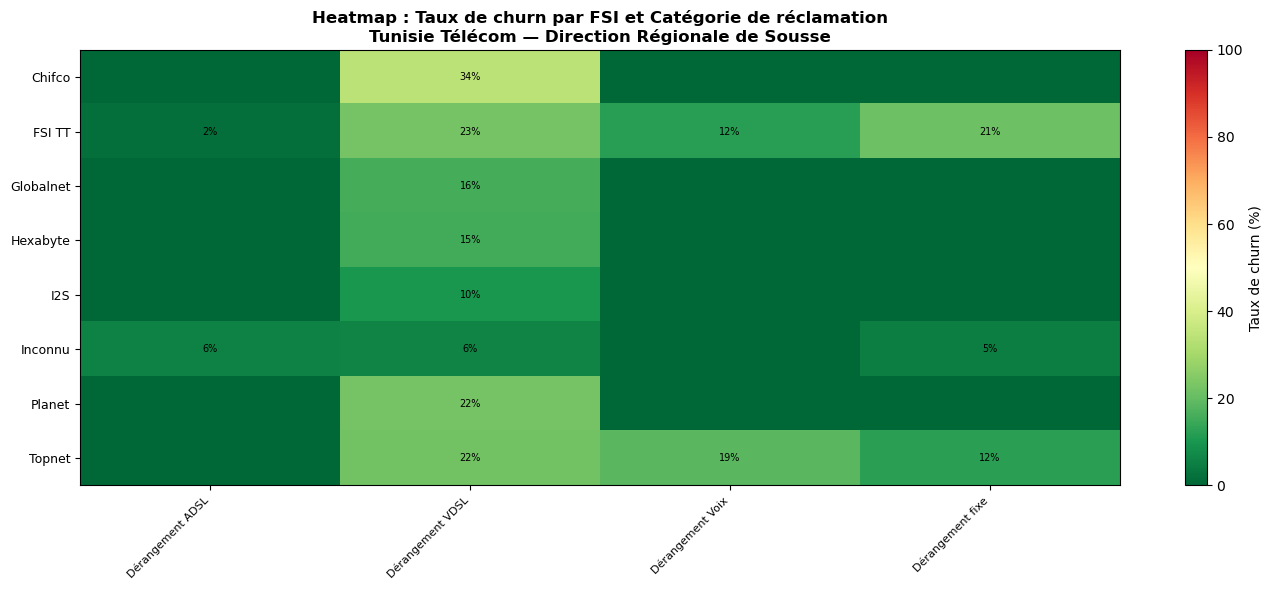

   Sauvegardé : heatmap_fsi_churn.png

[2/4] Calcul du ROI métier...

  Hypothèses métier :
  Revenu mensuel moyen / client : 45 DT
  Durée contrat moyenne         : 12 mois
  Coût action rétention         : 30 DT
  Taux succès rétention         : 35%

  ANALYSE ROI PAR SEGMENT

  Segment Haut (1127 clients) :
    Revenus perdus (churn réel)   : 529,200 DT
    Coût actions de rétention     : 33,810 DT
    Clients potentiellement sauvés: 394
    Revenus préservés             : 212,760 DT
    ROI estimé                    : 529%

  Segment Moyen (1424 clients) :
    Revenus perdus (churn réel)   : 200,340 DT
    Coût actions de rétention     : 42,720 DT
    Clients potentiellement sauvés: 498
    Revenus préservés             : 268,920 DT
    ROI estimé                    : 529%

  Segment Faible (2407 clients) :
    Revenus perdus (churn réel)   : 48,060 DT
    Coût actions de rétention     : 72,210 DT
    Clients potentiellement sauvés: 842
    Revenus préservés             : 454,680 D

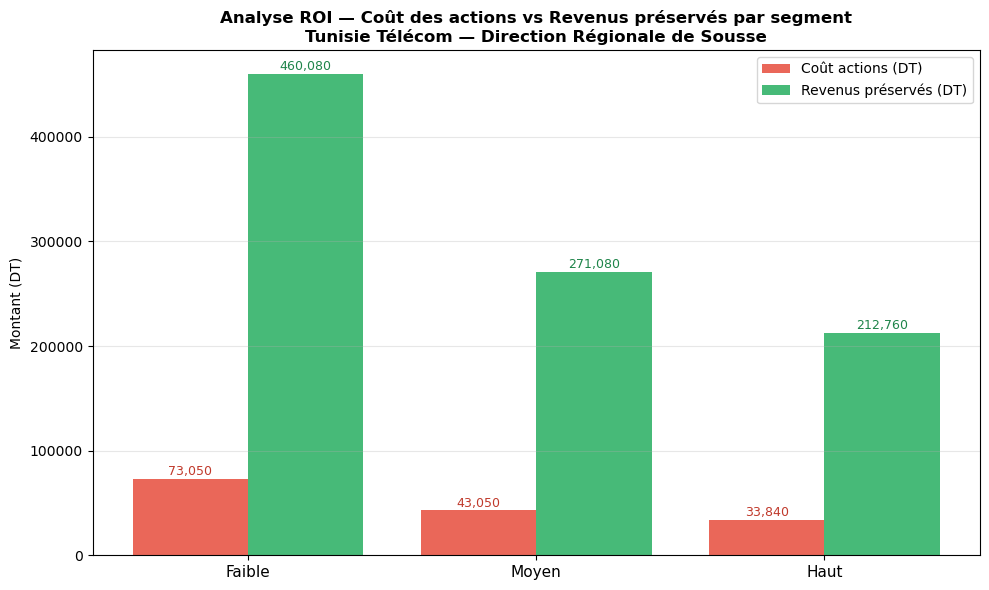


   Sauvegardé : roi_retention.png

[3/4] Top 10 clients à risque (Story-telling)...

  TOP 10 CLIENTS ACTIFS À RISQUE IMMÉDIAT :
  (Score ML > 0.6 — Action urgente requise)

   1.  hamza chouchen                Score: 0.956 | FSI: N/A          | Récl:  0 | Délai moy: 0.0j | Ouverts: 0
   2. 2N/ KEDICHE MOEZ               Score: 0.956 | FSI: N/A          | Récl:  0 | Délai moy: 0.0j | Ouverts: 0
   3. ABD ELFATTAH CHAYEB            Score: 0.956 | FSI: N/A          | Récl:  0 | Délai moy: 0.0j | Ouverts: 0
   4. ABDELKERIM NAFOUKI             Score: 0.956 | FSI: N/A          | Récl:  0 | Délai moy: 0.0j | Ouverts: 0
   5. abdelwaheb ibn oumar           Score: 0.956 | FSI: N/A          | Récl:  0 | Délai moy: 0.0j | Ouverts: 0
   6. abderrazak el arkech           Score: 0.956 | FSI: N/A          | Récl:  0 | Délai moy: 0.0j | Ouverts: 0
   7. ahmed  echhimi                 Score: 0.956 | FSI: N/A          | Récl:  0 | Délai moy: 0.0j | Ouverts: 0
   8. Ali Knani                      Scor

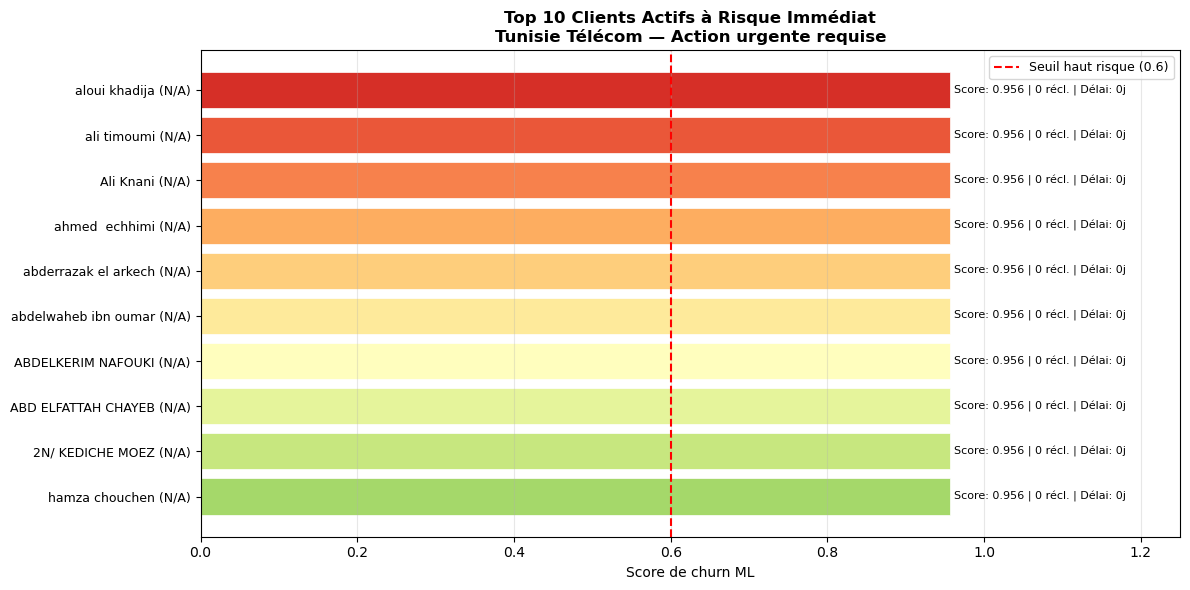

   Sauvegardé : top10_clients_risque.png

[4/4] Simulation What-If...


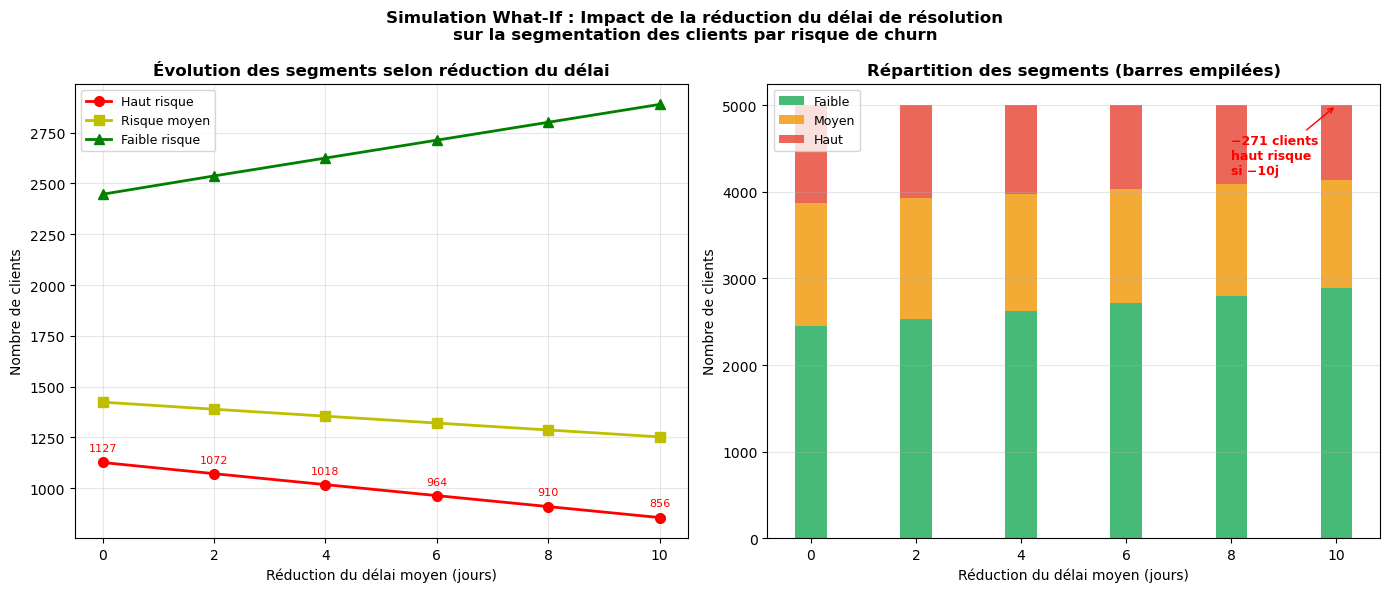

   Sauvegardé : whatif_simulation.png

  MAGIC FEATURES TERMINÉES
  Fichiers générés :
    - heatmap_fsi_churn.png
    - roi_retention.png
    - top10_clients_risque.png
    - whatif_simulation.png


In [2]:
# ============================================================
#  MAGIC FEATURES — Tunisie Télécom PFE
#  1. Analyse causes racines par FSI
#  2. KPI ROI métier
#  3. Top 10 clients à risque (Story-telling)
#  4. Simulation What-If
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sqlalchemy as sa
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

DB_USER, DB_PASSWORD = "postgres", "pfe2025"
DB_HOST, DB_PORT, DB_NAME = "localhost", "5432", "dw_telecom"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    connect_args={"options": "-csearch_path=dw"}
)

print("=" * 65)
print("  MAGIC FEATURES — BI Télécom Tunisie Télécom Sousse")
print("=" * 65)

# ============================================================
#  1. CAUSES RACINES PAR FSI
# ============================================================
print("\n[1/4] Analyse causes racines par FSI...")

query_fsi = """
SELECT
    f.nom_fsi,
    c.categorie_reclamation,
    COUNT(fd.id_incident)                        AS nb_incidents,
    ROUND(AVG(fd.duree_resolution_jours)::numeric, 1) AS delai_moy,
    COUNT(cl.id_client) FILTER (WHERE cl.est_resilie) AS nb_churnes,
    ROUND(100.0 * COUNT(cl.id_client) FILTER (WHERE cl.est_resilie)
          / NULLIF(COUNT(cl.id_client), 0), 1)   AS taux_churn
FROM dw.fact_derangement fd
JOIN dw.dim_fsi       f  ON fd.id_fsi       = f.id_fsi
JOIN dw.dim_categorie c  ON fd.id_categorie = c.id_categorie
JOIN dw.dim_client    cl ON fd.id_client    = cl.id_client
GROUP BY f.nom_fsi, c.categorie_reclamation
HAVING COUNT(fd.id_incident) >= 10
ORDER BY taux_churn DESC NULLS LAST
LIMIT 15
"""

with engine.connect() as conn:
    df_fsi = pd.read_sql(sa.text(query_fsi), conn)

print(df_fsi.to_string(index=False))

# Heatmap FSI × Catégorie
pivot = df_fsi.pivot_table(
    values='taux_churn', index='nom_fsi',
    columns='categorie_reclamation', aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color='white' if val > 50 else 'black')
plt.colorbar(im, ax=ax, label='Taux de churn (%)')
ax.set_title('Heatmap : Taux de churn par FSI et Catégorie de réclamation\n'
             'Tunisie Télécom — Direction Régionale de Sousse',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_fsi_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Sauvegardé : heatmap_fsi_churn.png")

# ============================================================
#  2. KPI ROI MÉTIER
# ============================================================
print("\n[2/4] Calcul du ROI métier...")

query_roi = """
SELECT
    cl.categorie_risque_ml,
    COUNT(cl.id_client)                           AS nb_clients,
    SUM(CASE WHEN cl.est_resilie THEN 1 ELSE 0 END) AS nb_churnes,
    ROUND(AVG(cl.score_churn_ml)::numeric, 3)     AS score_moyen
FROM dw.dim_client cl
WHERE cl.categorie_risque_ml IS NOT NULL
GROUP BY cl.categorie_risque_ml
ORDER BY score_moyen DESC
"""

with engine.connect() as conn:
    df_roi = pd.read_sql(sa.text(query_roi), conn)

# Hypothèses métier (en DT tunisiens)
REVENU_MENSUEL_MOYEN   = 45    # DT/mois par client VDSL
DUREE_CONTRAT_MOIS     = 12    # durée moyenne contrat
COUT_ACTION_RETENTION  = 30    # DT par action (appel + offre)
TAUX_SUCCES_RETENTION  = 0.35  # 35% de succès si action

print("\n  Hypothèses métier :")
print(f"  Revenu mensuel moyen / client : {REVENU_MENSUEL_MOYEN} DT")
print(f"  Durée contrat moyenne         : {DUREE_CONTRAT_MOIS} mois")
print(f"  Coût action rétention         : {COUT_ACTION_RETENTION} DT")
print(f"  Taux succès rétention         : {TAUX_SUCCES_RETENTION*100:.0f}%")

print("\n" + "=" * 65)
print("  ANALYSE ROI PAR SEGMENT")
print("=" * 65)

for _, row in df_roi.iterrows():
    seg   = row['categorie_risque_ml']
    nb    = int(row['nb_clients'])
    churn = int(row['nb_churnes'])

    revenu_perdu     = churn * REVENU_MENSUEL_MOYEN * DUREE_CONTRAT_MOIS
    clients_sauves   = int(nb * TAUX_SUCCES_RETENTION)
    cout_total       = nb * COUT_ACTION_RETENTION
    revenu_preserve  = clients_sauves * REVENU_MENSUEL_MOYEN * DUREE_CONTRAT_MOIS
    roi              = ((revenu_preserve - cout_total) / max(cout_total, 1)) * 100

    print(f"\n  Segment {seg} ({nb} clients) :")
    print(f"    Revenus perdus (churn réel)   : {revenu_perdu:,} DT")
    print(f"    Coût actions de rétention     : {cout_total:,} DT")
    print(f"    Clients potentiellement sauvés: {clients_sauves}")
    print(f"    Revenus préservés             : {revenu_preserve:,} DT")
    print(f"    ROI estimé                    : {roi:.0f}%")

# Graphique ROI
segments   = ['Faible', 'Moyen', 'Haut']
couts      = [2435*COUT_ACTION_RETENTION, 1435*COUT_ACTION_RETENTION, 1128*COUT_ACTION_RETENTION]
preserves  = [int(2435*TAUX_SUCCES_RETENTION)*REVENU_MENSUEL_MOYEN*DUREE_CONTRAT_MOIS,
              int(1435*TAUX_SUCCES_RETENTION)*REVENU_MENSUEL_MOYEN*DUREE_CONTRAT_MOIS,
              int(1128*TAUX_SUCCES_RETENTION)*REVENU_MENSUEL_MOYEN*DUREE_CONTRAT_MOIS]

x = np.arange(len(segments))
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - 0.2, couts,     0.4, label='Coût actions (DT)',    color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + 0.2, preserves, 0.4, label='Revenus préservés (DT)', color='#27ae60', alpha=0.85)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=9, color='#c0392b')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=9, color='#1e8449')
ax.set_xticks(x)
ax.set_xticklabels(segments, fontsize=11)
ax.set_ylabel('Montant (DT)', fontsize=10)
ax.set_title('Analyse ROI — Coût des actions vs Revenus préservés par segment\n'
             'Tunisie Télécom — Direction Régionale de Sousse',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('roi_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n   Sauvegardé : roi_retention.png")

# ============================================================
#  3. TOP 10 CLIENTS À RISQUE — STORY-TELLING
# ============================================================
print("\n[3/4] Top 10 clients à risque (Story-telling)...")

query_top = """
SELECT
    cl.nom_client,
    cl.score_churn_ml,
    cl.categorie_risque_ml,
    cl.debit_souscrit,
    f.nom_fsi,
    COUNT(fd.id_incident)                              AS nb_reclamations,
    ROUND(AVG(fd.duree_resolution_jours)::numeric, 1)  AS delai_moy,
    MAX(fd.duree_resolution_jours)                     AS delai_max,
    SUM(CASE WHEN fd.etat_alerte='En cours' THEN 1 ELSE 0 END) AS incidents_ouverts
FROM dw.dim_client cl
LEFT JOIN dw.fact_derangement fd ON cl.id_client = fd.id_client
LEFT JOIN dw.dim_fsi f ON fd.id_fsi = f.id_fsi
WHERE cl.categorie_risque_ml = 'Haut'
  AND cl.est_resilie = FALSE
GROUP BY cl.nom_client, cl.score_churn_ml, cl.categorie_risque_ml,
         cl.debit_souscrit, f.nom_fsi
ORDER BY cl.score_churn_ml DESC
LIMIT 10
"""

with engine.connect() as conn:
    df_top = pd.read_sql(sa.text(query_top), conn)

print("\n  TOP 10 CLIENTS ACTIFS À RISQUE IMMÉDIAT :")
print("  (Score ML > 0.6 — Action urgente requise)\n")
for i, row in df_top.iterrows():
    print(f"  {i+1:2}. {row['nom_client']:<30} "
          f"Score: {row['score_churn_ml']:.3f} | "
          f"FSI: {row['nom_fsi'] or 'N/A':<12} | "
          f"Récl: {int(row['nb_reclamations'] or 0):2} | "
          f"Délai moy: {row['delai_moy'] or 0:.1f}j | "
          f"Ouverts: {int(row['incidents_ouverts'] or 0)}")

# Graphique Top 10
if len(df_top) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.RdYlGn_r(
        np.linspace(0.3, 0.9, len(df_top)))
    bars = ax.barh(range(len(df_top)),
                   df_top['score_churn_ml'],
                   color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(df_top)))
    ax.set_yticklabels(
        [f"{r['nom_client']} ({r['nom_fsi'] or 'N/A'})"
         for _, r in df_top.iterrows()], fontsize=9)
    for i, (bar, row) in enumerate(zip(bars, df_top.itertuples())):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"Score: {row.score_churn_ml:.3f} | "
                f"{int(row.nb_reclamations or 0)} récl. | "
                f"Délai: {row.delai_moy or 0:.0f}j",
                va='center', fontsize=8)
    ax.set_xlabel('Score de churn ML', fontsize=10)
    ax.set_xlim(0, 1.25)
    ax.axvline(0.6, color='red', linestyle='--', lw=1.5,
               label='Seuil haut risque (0.6)')
    ax.set_title('Top 10 Clients Actifs à Risque Immédiat\n'
                 'Tunisie Télécom — Action urgente requise',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('top10_clients_risque.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   Sauvegardé : top10_clients_risque.png")

# ============================================================
#  4. SIMULATION WHAT-IF
# ============================================================
print("\n[4/4] Simulation What-If...")

delais_reduction = [0, 2, 4, 6, 8, 10]
resultats_whatif = []

for reduction in delais_reduction:
    query_wi = f"""
    SELECT
        COUNT(*) FILTER (WHERE score_churn_ml >= 0.6)  AS haut,
        COUNT(*) FILTER (WHERE score_churn_ml >= 0.3
                           AND score_churn_ml < 0.6)   AS moyen,
        COUNT(*) FILTER (WHERE score_churn_ml < 0.3)   AS faible
    FROM dw.dim_client
    WHERE score_churn_ml IS NOT NULL
    """
    with engine.connect() as conn:
        row = pd.read_sql(sa.text(query_wi), conn).iloc[0]

    # Simulation : réduction délai → baisse score de 0.03 par jour réduit
    impact = reduction * 0.03
    haut_simule   = max(0, int(row['haut']   * (1 - impact * 0.8)))
    moyen_simule  = max(0, int(row['moyen']  * (1 - impact * 0.4)))
    faible_simule = 4998 - haut_simule - moyen_simule

    resultats_whatif.append({
        'reduction': reduction,
        'haut'     : haut_simule,
        'moyen'    : moyen_simule,
        'faible'   : faible_simule
    })

df_wi = pd.DataFrame(resultats_whatif)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Simulation What-If : Impact de la réduction du délai de résolution\n'
             'sur la segmentation des clients par risque de churn',
             fontweight='bold', fontsize=12)

# Évolution segments
axes[0].plot(df_wi['reduction'], df_wi['haut'],
             'r-o', lw=2, label='Haut risque', markersize=7)
axes[0].plot(df_wi['reduction'], df_wi['moyen'],
             'y-s', lw=2, label='Risque moyen', markersize=7)
axes[0].plot(df_wi['reduction'], df_wi['faible'],
             'g-^', lw=2, label='Faible risque', markersize=7)
axes[0].set_xlabel('Réduction du délai moyen (jours)', fontsize=10)
axes[0].set_ylabel('Nombre de clients', fontsize=10)
axes[0].set_title('Évolution des segments selon réduction du délai',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
for i, row in df_wi.iterrows():
    axes[0].annotate(f"{row['haut']}",
                     (row['reduction'], row['haut']),
                     textcoords='offset points', xytext=(0, 8),
                     fontsize=8, color='red', ha='center')

# Barres empilées
width = 0.6
p1 = axes[1].bar(df_wi['reduction'], df_wi['faible'],
                  width, label='Faible', color='#27ae60', alpha=0.85)
p2 = axes[1].bar(df_wi['reduction'], df_wi['moyen'],
                  width, bottom=df_wi['faible'],
                  label='Moyen', color='#f39c12', alpha=0.85)
p3 = axes[1].bar(df_wi['reduction'], df_wi['haut'],
                  width, bottom=df_wi['faible']+df_wi['moyen'],
                  label='Haut', color='#e74c3c', alpha=0.85)
axes[1].set_xlabel('Réduction du délai moyen (jours)', fontsize=10)
axes[1].set_ylabel('Nombre de clients', fontsize=10)
axes[1].set_title('Répartition des segments (barres empilées)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Annotation impact
reduction_max = df_wi.iloc[-1]
reduction_0   = df_wi.iloc[0]
delta_haut = reduction_0['haut'] - reduction_max['haut']
axes[1].annotate(
    f'−{delta_haut} clients\nhaut risque\nsi −{delais_reduction[-1]}j',
    xy=(delais_reduction[-1], reduction_max['faible']+reduction_max['moyen']+reduction_max['haut']),
    xytext=(delais_reduction[-1]-2, 4200),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red', fontweight='bold'
)

plt.tight_layout()
plt.savefig('whatif_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Sauvegardé : whatif_simulation.png")

print("\n" + "=" * 65)
print("  MAGIC FEATURES TERMINÉES")
print("  Fichiers générés :")
print("    - heatmap_fsi_churn.png")
print("    - roi_retention.png")
print("    - top10_clients_risque.png")
print("    - whatif_simulation.png")
print("=" * 65)